# E-Commerce Transactions Analysis.

### Task-1 Dataset Understanding.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Loading the Dataset
df = pd.read_csv(r"Data/OnlineRetail.csv",encoding = "latin1")

In [3]:
# Showing first few rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# Number of rows and columns
df.shape

(541909, 8)

In [5]:
# Data types
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
# Finding missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# Identifying numerical and categorical Data
df.select_dtypes(include = 'number').columns.tolist()


['Quantity', 'UnitPrice', 'CustomerID']

In [9]:
df.select_dtypes(include = 'object').columns.tolist()

C:\Users\Yvvone\AppData\Local\Temp\ipykernel_8904\1901505741.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include = 'object').columns.tolist()


['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']

In [10]:
df['InvoiceNo'].nunique()

25900

In [11]:
# Finding Primary Key
df['CustomerID'].duplicated().sum()

np.int64(537536)

# Tak -1 Summary Dataset Description
- Dataset had 541909 rows and 8 columns
- InvoiceDate has str datatype
- Quantity,UnitPrice and CustomerId are numerical data
- InvoiceNo,StockCode,Description,InvoiceDate and Country are categorical data
- No primary key since InvoiceNo and CustomerId have duplicates and null values.


# Task-2 Data Cleaning


### Handling Missing values

In [12]:
#Finding the number of missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [17]:
#Filling missing description with unkown
df['Description'] = df['Description'].fillna('Unknown',inplace=True)

C:\Users\Yvvone\AppData\Local\Temp\ipykernel_8904\112598833.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Description'] = df['Description'].fillna('Unknown',inplace=True)


In [18]:
#Filling CustomerID with 0
df['CustomerID'] = df['CustomerID'].fillna(0,inplace=True)

C:\Users\Yvvone\AppData\Local\Temp\ipykernel_8904\367161838.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['CustomerID'] = df['CustomerID'].fillna(0,inplace=True)


In [19]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Duplicate Records

In [20]:
#Checking for Duplicates
df.duplicated().sum()

np.int64(5268)

In [29]:
#Dropping Duplicates
df = df.drop_duplicates().reset_index(drop=True)

print(f"Rows before: 541909")
print(f"Rows after removing duplicates: {len(df)}")
print(f"Duplicates removed: 5268")

Rows before: 541909
Rows after removing duplicates: 536641
Duplicates removed: 5268


In [30]:
df.duplicated().sum()

np.int64(0)

### Standardization

In [31]:
# Column names to lowercase
df.columns = df.columns.str.lower()

In [37]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='str')

In [34]:
# Text columns to upper case
df['description']= df['description'].str.upper()
df['country'] = df['country'].str.upper()

In [ ]:
df['description']

0          WHITE HANGING HEART T-LIGHT HOLDER
1                         WHITE METAL LANTERN
2              CREAM CUPID HEARTS COAT HANGER
3         KNITTED UNION FLAG HOT WATER BOTTLE
4              RED WOOLLY HOTTIE WHITE HEART.
                         ...                 
536636            PACK OF 20 SPACEBOY NAPKINS
536637           CHILDREN'S APRON DOLLY GIRL 
536638          CHILDRENS CUTLERY DOLLY GIRL 
536639        CHILDRENS CUTLERY CIRCUS PARADE
536640          BAKING SET 9 PIECE RETROSPOT 
Name: description, Length: 536641, dtype: str

In [38]:
df['country']

0         UNITED KINGDOM
1         UNITED KINGDOM
2         UNITED KINGDOM
3         UNITED KINGDOM
4         UNITED KINGDOM
               ...      
536636            FRANCE
536637            FRANCE
536638            FRANCE
536639            FRANCE
536640            FRANCE
Name: country, Length: 536641, dtype: str

In [ ]:
#Fixing invoicedate to datetime format
df['invoicedate'] = pd.to_datetime(df['invoicedate'])


In [41]:
#Fixing customerid from float to integer
df['customerid'] = df['customerid'].astype(int)

In [42]:
df.dtypes

invoiceno                 str
stockcode                 str
description               str
quantity                int64
invoicedate    datetime64[us]
unitprice             float64
customerid              int64
country                   str
dtype: object

### Data Validation


In [46]:
# Checking for negative quantity items
print (df[df['quantity'] < 0].shape)

(10587, 8)


In [49]:
# Removing negative quantity values
df = df[df['quantity'] > 0].reset_index(drop=True)

In [47]:
# Cheking for negative unitprice
print(df[df['unitprice'] <= 0].shape)

(2512, 8)


In [50]:
#Removing negative unitprice
df = df[df['unitprice'] > 0].reset_index(drop=True)

In [ ]:
 #checking for invalid invoiceno  some might start with 'C' to show cancellations
print(df[df['invoiceno'].astype(str).str.startswith('C')].shape)

(9251, 8)


In [51]:
#Dropping invalid invoiceno
df = df[~df['invoiceno'].astype(str).str.startswith('C')].reset_index(drop=True)

In [52]:
df.shape

(524878, 8)

### Cleaning Summary


| Issue Found | Details | Action Taken |
|-------------|---------|--------------|
| Missing Values (Description) | 1,454 missing | Filled with 'Unknown' |
| Missing Values (CustomerID) | 135,080 missing | Filled with '0 |
| Duplicate Rows | 5,268 duplicates | Removed all duplicates |
| Column Names | Inconsistent casing | Lowercased all column names |
| Text Columns | Inconsistent casing | Uppercased Description and Country |
| InvoiceDate | Stored as string | Converted to datetime |
| CustomerID | Stored as float | Converted to integer |
| Negative Quantity | 10,587 rows | Removed all rows |
| Zero/Negative UnitPrice | 2,512 rows | Removed all rows |
| Cancelled Invoices | 9,251 rows | Removed all rows |

### Task-2 summary on cleaning
- Started with 541,909 rows and 8 columns
- Fixed missing values in 2 columns
- Removed 5,268 duplicate rows
- Standardized column names, text casing, date and data types
-Removed 22,031 invalid/cancelled records
- Ended with a clean dataset of 524,878 rows
- Dataset is now ready for analysis

# Task-3 Exploratory Data Analysis EDA

### Summary statistics

In [58]:
df.describe()

,quantity,invoicedate,unitprice,customerid
count,524878.000000,524878,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049,3.922573,11437.732164
min,1.000000,2010-12-01 08:26:00,0.001000,0.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,0.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,14350.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16245.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,156.280031,NaN,36.093028,6799.513627


- Average quantity per line item is 10 units with a very high max of 80,995 (bulk orders)
- Average unit price is £3.92 with a max of £13,541 (possible premium/special items)
- Data covers one full year: December 2010 to December 2011
- CustomerID min of 0 represents unidentified/guest customers

### Creating Revenue column

In [59]:
df['revenue'] = df['quantity'] * df['unitprice']

In [60]:
df[['revenue','quantity','unitprice']].head()

,revenue,quantity,unitprice
0,15.30,6,2.55
1,20.34,6,3.39
2,22.00,8,2.75
3,20.34,6,3.39
4,20.34,6,3.39


### Top 10 Best selling products


In [61]:
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: quantity, dtype: int64


### Top 10 Revenue generating countries

In [62]:
top_countries = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_countries)

country
UNITED KINGDOM    9001744.094
NETHERLANDS        285446.340
EIRE               283140.520
GERMANY            228678.400
FRANCE             209625.370
AUSTRALIA          138453.810
SPAIN               61558.560
SWITZERLAND         57067.600
BELGIUM             41196.340
SWEDEN              38367.830
Name: revenue, dtype: float64


### Monthly sales trends

In [64]:
df['month']=df['invoicedate'].dt.to_period('M')
monthly_sales = df.groupby('month')['revenue'].sum().sort_index()
print(monthly_sales)

month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: revenue, dtype: float64


### Top 10 customers by revenue


In [68]:
top_customers = df[df['customerid'] != 0].groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

customerid
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: revenue, dtype: float64


### Top 10 countries by number of orders

In [69]:
top_orders = df.groupby('country')['invoiceno'].nunique().sort_values(ascending=False).head(10)
print(top_orders)

country
UNITED KINGDOM    18019
GERMANY             457
FRANCE              392
EIRE                288
BELGIUM              98
NETHERLANDS          94
SPAIN                90
PORTUGAL             58
AUSTRALIA            57
SWITZERLAND          54
Name: invoiceno, dtype: int64


### Task-3 Summary
- Created a revenue column (quantity × unitprice)
- Top selling product is PAPER CRAFT, LITTLE BIRDIE with 80,995 units
- United Kingdom generates the most revenue at £9 million (dominates all other countries)
- Revenue peaks in November 2011 suggesting strong holiday/Christmas shopping season
- Customer 14646 is the highest spending customer at £280,206
- United Kingdom also leads in number of orders with 18,019 confirming it as the primary market
- Data covers December 2010 to December 2011

# Task-4 Visualizations

### Top 10 best performing products(Barchart)

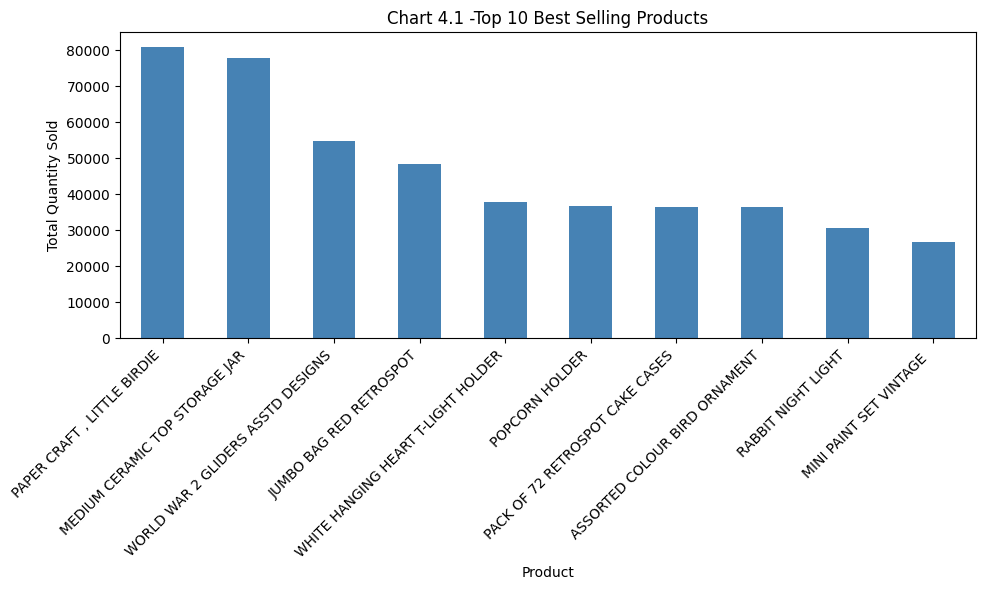

In [89]:
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='steelblue')
plt.title('Chart 4.1 -Top 10 Best Selling Products')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** PAPER CRAFT, LITTLE BIRDIE is the best selling product 
with 80,995 units sold, significantly ahead of all other products.

### Top 10 revenue generating countries (Barchart)

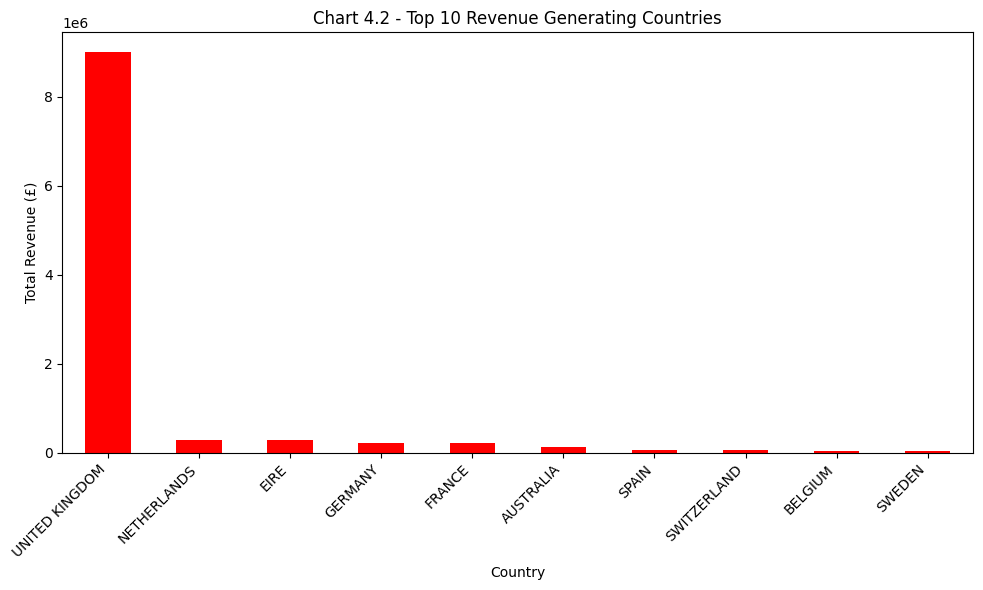

In [90]:
plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='red')
plt.title('Chart 4.2 - Top 10 Revenue Generating Countries')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** United Kingdom dominates revenue at £9 million, 
far ahead of Netherlands in second place at £285,446. 
This confirms the store is primarily a UK-based retailer.

### Monthly sales trends (Linechart)

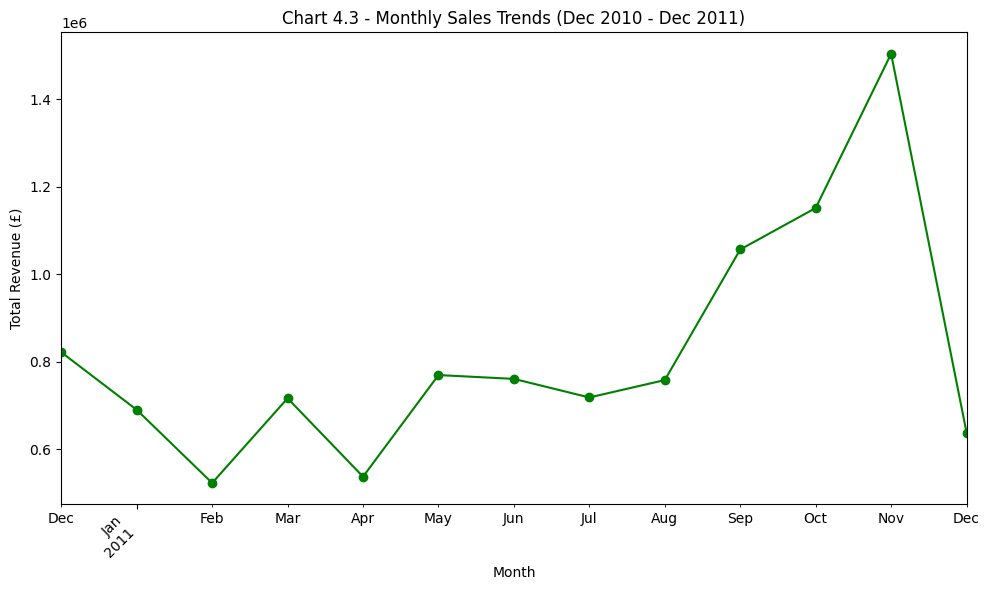

In [91]:
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', color='green', marker='o')
plt.title('Chart 4.3 - Monthly Sales Trends (Dec 2010 - Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** Revenue steadily increases from September 2011 
peaking in November 2011 at £1.5 million, indicating a strong 
holiday and Christmas shopping season.

### Top 10 customers by revenue (Barchart)

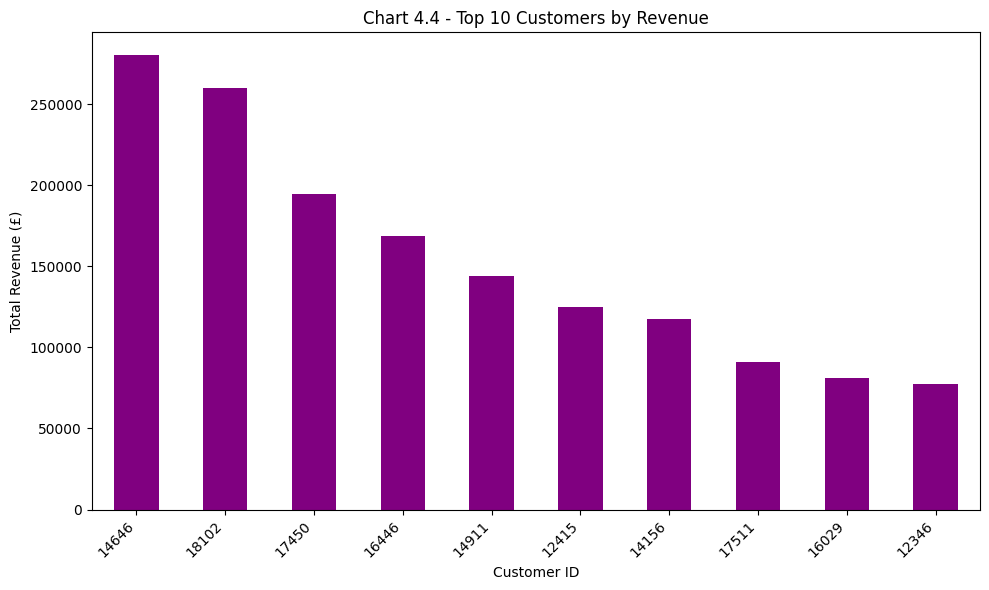

In [92]:
plt.figure(figsize=(10, 6))
top_customers.plot(kind='bar', color='purple')
plt.title('Chart 4.4 - Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** Customer 14646 is the highest spending customer at 
£280,206 followed by Customer 18102 at £259,657. These are likely 
wholesale or bulk buyers given the large gap between them and 
regular customers.

### Distribution of unitprice (Histogram)

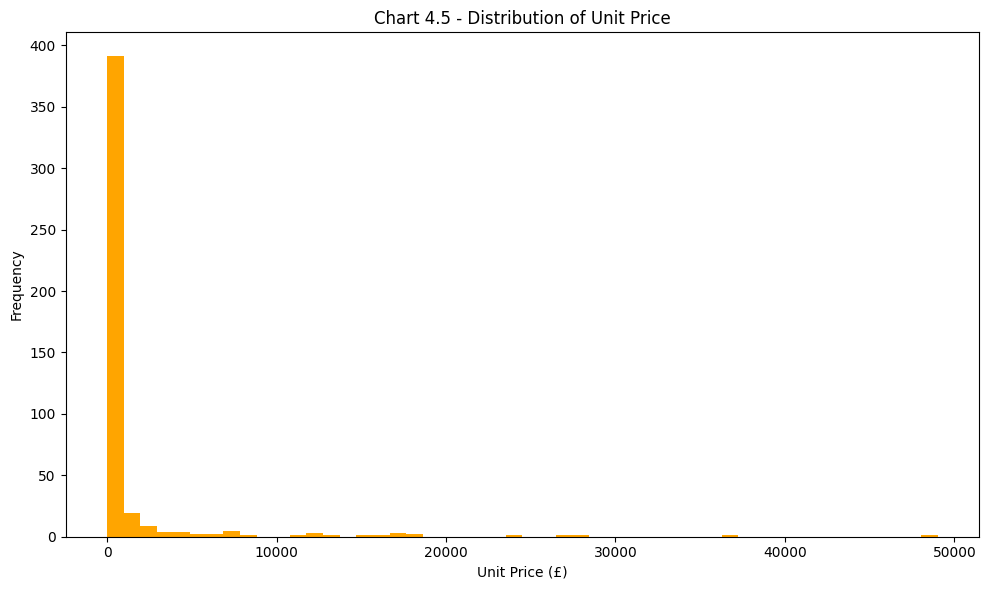

In [93]:
plt.figure(figsize=(10, 6))
df[df['unitprice'] < 20].groupby('unitprice').size().plot(kind='hist', bins=50, color='orange')
plt.title('Chart 4.5 - Distribution of Unit Price')
plt.xlabel('Unit Price (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Finding:** Most products are priced below £5, confirming this 
is a low-cost retail store. Very few products are priced above 
£10, and the extreme high prices seen in summary statistics 
are rare outliers.

### Top 10 countries by orders (Pie Chart)

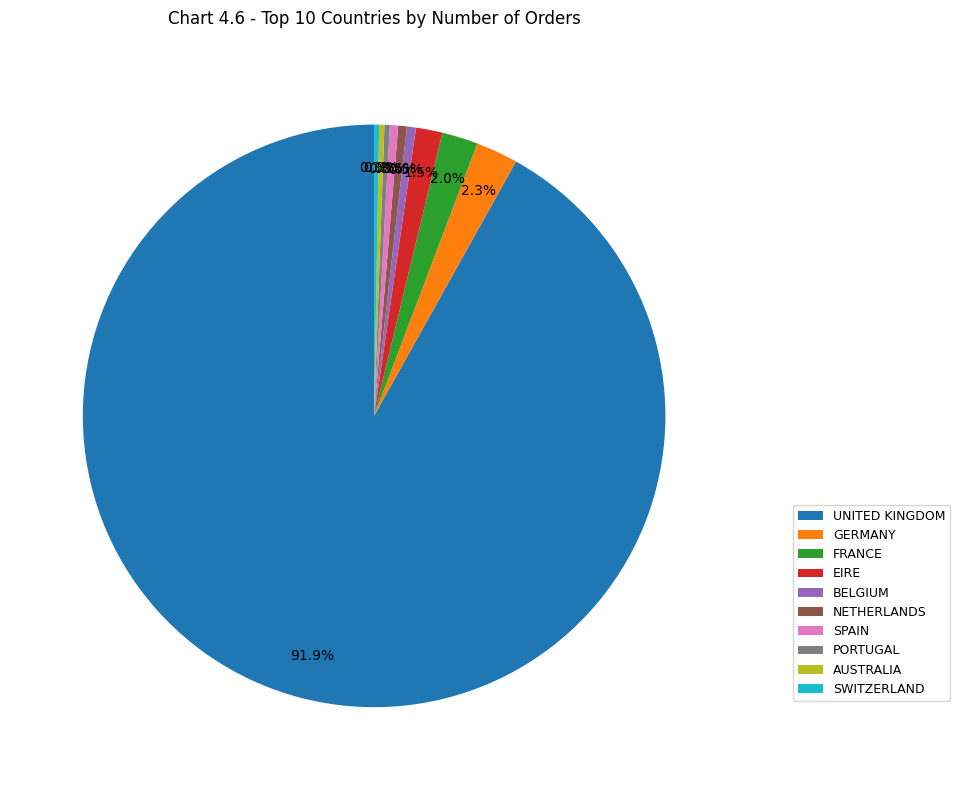

In [94]:
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(top_orders, 
                                    labels=None,
                                    autopct='%1.1f%%',
                                    pctdistance=0.85,
                                    startangle=90)
plt.legend(wedges, top_orders.index, 
           loc='lower right', 
           bbox_to_anchor=(1.3, 0.1),
           fontsize=9)
plt.title('Chart 4.6 - Top 10 Countries by Number of Orders', pad=20)
plt.tight_layout()
plt.show()

**Finding:** United Kingdom accounts for the overwhelming majority 
of orders, confirming it as the primary market for this retailer.

### Distribution of quantity per order (Boxplot)

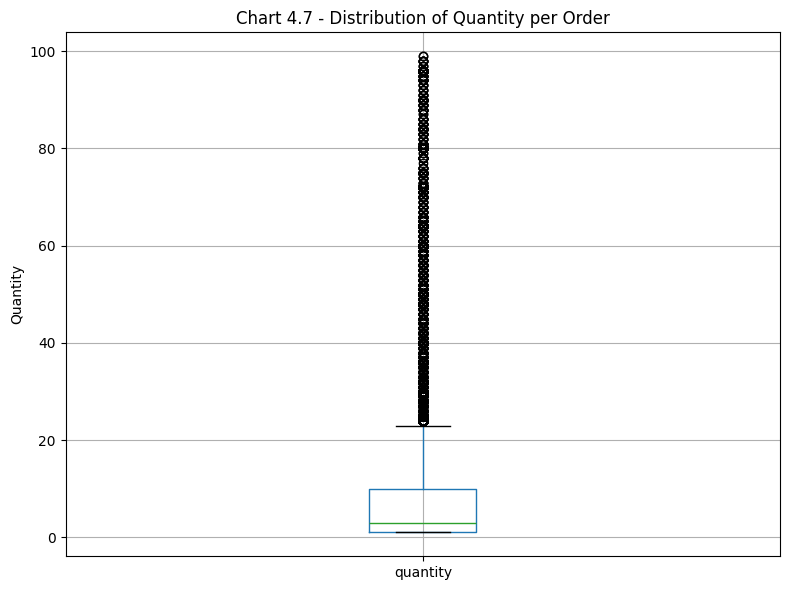

In [95]:
plt.figure(figsize=(8, 6))
df[df['quantity'] < 100].boxplot(column='quantity')
plt.title('Chart 4.7 - Distribution of Quantity per Order')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

**Finding:** Most orders contain fewer than 20 units. 
The many outliers above the whiskers confirm that bulk 
orders exist but are not typical customer behavior.

### Task-4 visalizations summary
- Created 7 visualizations covering products, countries, trends, customers,orders and pricing
- All charts have titles, axis labels and findings
- Charts confirm UK dominance, holiday season surge and low-cost product pricing

# Task-5 Insights

### Insight 1 — United Kingdom is the Dominant Market
The United Kingdom accounts for the vast majority of both revenue 
(£9 million) and orders (18,019) compared to all other countries. 
The next highest country, Netherlands, generates only £285,446 in 
revenue. This suggests the business is heavily UK-focused and 
could explore strategies to grow international markets.
(Supported by: Charts 4.2 and 4.6)

### Insight 2 — Revenue Peaks During Holiday Season
Monthly sales data shows a steady revenue increase from September 
2011, peaking in November 2011 at £1.5 million. This indicates 
strong Christmas and holiday shopping behavior. The business 
should stock up and prepare marketing campaigns from September onwards.
(Supported by: Chart 4.3)

### Insight 3 — A Small Group of Customers Drive High Revenue
The top 10 customers contribute significantly to total revenue, 
with Customer 14646 alone spending £280,206. These are likely 
wholesale or bulk buyers. Retaining these customers through 
loyalty programs would be critical to business performance.
(Supported by: Chart 4.4)

### Insight 4 — Most Products are Low Cost
The histogram shows that the majority of products are priced 
below £5, confirming this is a low-cost retail store. The 
extreme high prices in the summary statistics are rare outliers 
and not representative of typical pricing.
(Supported by: Chart 4.5)

### Insight 5 — Bulk Orders are Rare but Significant
The box plot shows most orders contain fewer than 20 units. 
However, outliers like PAPER CRAFT, LITTLE BIRDIE with 80,995 
units show that bulk orders exist and heavily influence total 
quantity statistics. These bulk orders are likely from 
wholesale customers.
(Supported by: Charts 4.1 and 4.7)

In [96]:
df.to_csv(r'Data/OnlineRetail_cleaned.csv', index=False)